### Explicación del Dataset
El Glass dataset es un dataset forense. Proviene de investigaciones criminológicas donde se analizaban fragmentos de vidrio encontrados en escenas del crimen.
El objetivo es clasificar el tipo de vidrio a partir de su composición química.

### Librerias necesarias para llevar acabo la actividad

In [1]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


### Imports necesarios para la actividad

In [2]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Descargamos el conjunto de datos

NOTA: En este apartado solo descargamos el data set y lo guardamos en CSV

In [23]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Cargamos el dataset
glass = fetch_openml(name='glass', version=1, as_frame=False)

le = LabelEncoder()

# Convertimos las clases a números
target = le.fit_transform(glass.target).reshape(-1, 1).astype(float)

# Unimos las etiquetas (clases) con los datos de entrada
dataset = np.hstack([target, glass.data])

# Guardamos el dataset en un archivo CSV
np.savetxt('Datasets/glass.csv', dataset, delimiter=',')

# Mostramos las clases originales del dataset
print("Clases:", le.classes_)

Clases: ['build wind float' 'build wind non-float' 'containers' 'headlamps'
 'tableware' 'vehic wind float']


### Cargamos el CSV

In [24]:
data = pd.read_csv("Datasets/glass.csv", header=None)
X = data.iloc[:, 1:]   # todas las columnas menos la primera
y = data.iloc[:, 0:1]  # solo la primera columna (salida)

### Codificar la variable categórica

In [5]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(y)
#Ignora las categorías desconocidas y con sparse_output a True controlaría por eficiencia las salida del encoder devolviendo una matriz dispersa
y = ohe.transform(y)
y

array([[1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0.],
       ...,
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.]], shape=(214, 6))

In [6]:
# Este bloque convierte los datos de formato numpy/pandas a tensores de PyTorch.
X = torch.tensor(X.values, dtype=torch.float32)  # features a tensor
y = torch.tensor(y, dtype=torch.float32)
X

tensor([[ 1.5179, 12.7900,  3.5000,  ...,  8.7700,  0.0000,  0.0000],
        [ 1.5164, 12.1600,  3.5200,  ...,  8.5300,  0.0000,  0.0000],
        [ 1.5179, 13.2100,  3.4800,  ...,  8.4300,  0.0000,  0.0000],
        ...,
        [ 1.5161, 13.9200,  3.5200,  ...,  7.9400,  0.0000,  0.1400],
        [ 1.5169, 12.6700,  2.8800,  ...,  8.5400,  0.0000,  0.0000],
        [ 1.5185, 14.0900,  2.1900,  ...,  9.3200,  0.0000,  0.0000]])

In [8]:
# Dividimos el dataset en dos partes
# 70% train — 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

### Definir el modelo de red neuronal

In [12]:
class Multiclass(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(9, 16)
        self.act = nn.ReLU()
        self.output = nn.Linear(16, 7)

    def forward(self, x):
        x = self.act(self.hidden(x))
        x = self.output(x)
        return x
        

In [13]:
model = Multiclass()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

### Evaluamos el modelo 

In [17]:
# prepare model and training parameters
n_epochs = 200
batch_size = 5
batches_per_epoch = len(X_train) // batch_size

best_acc = 0
best_weights = None
train_loss_hist = []
train_acc_hist = []
test_loss_hist = []
test_acc_hist = []

# training loop
for epoch in range(n_epochs):
    epoch_loss = []
    epoch_acc = []
    model.train()
    with tqdm.trange(batches_per_epoch, unit="batch", mininterval=0) as bar:
        bar.set_description(f"Epoch {epoch}")
        for i in bar:
            # take a batch
            start = i * batch_size
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, torch.argmax(y_batch, 1))  # convierte one-hot a índice de clase            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # compute and store metrics
            acc = (torch.argmax(y_pred, 1)==torch.argmax(y_batch, 1)).float().mean()
            #Obtenemos la clase con mayor probabilidad y calculamos la media. Se pregunta sobre qué dimensión se busca el máximo
            epoch_loss.append(float(loss))
            epoch_acc.append(float(acc))
            bar.set_postfix(
                loss=float(loss),
                acc=float(acc)
            )
    # set model in evaluation mode and run through the test set
    model.eval()
    y_pred = model(X_test)
    ce = loss = loss_fn(y_pred, torch.argmax(y_test, 1))  # convierte one-hot a índice de clase
    acc = (torch.argmax(y_pred, 1) == torch.argmax(y_test, 1)).float().mean()
    ce = float(ce)
    acc = float(acc)
    # save best model
    train_loss_hist.append(np.mean(epoch_loss))
    train_acc_hist.append(np.mean(epoch_acc))
    test_loss_hist.append(ce)
    test_acc_hist.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch} validation: Cross-entropy={ce:.2f}, Accuracy={acc*100:.1f}%")

Epoch 0: 100%|██████████| 29/29 [00:00<00:00, 782.76batch/s, acc=0, loss=1.83]  


Epoch 0 validation: Cross-entropy=2.04, Accuracy=35.4%


Epoch 1: 100%|██████████| 29/29 [00:00<00:00, 798.71batch/s, acc=0, loss=1.83]  


Epoch 1 validation: Cross-entropy=1.90, Accuracy=33.8%


Epoch 2: 100%|██████████| 29/29 [00:00<00:00, 867.27batch/s, acc=0, loss=1.84]  


...

Epoch 197 validation: Cross-entropy=1.06, Accuracy=55.4%


Epoch 198: 100%|██████████| 29/29 [00:00<00:00, 839.83batch/s, acc=0.4, loss=1.11] 


Epoch 198 validation: Cross-entropy=1.06, Accuracy=55.4%


Epoch 199: 100%|██████████| 29/29 [00:00<00:00, 848.28batch/s, acc=0.4, loss=1.11] 


Epoch 199 validation: Cross-entropy=1.06, Accuracy=55.4%


In [18]:
# Restauramos el mejor modelo
model.load_state_dict(best_weights)

<All keys matched successfully>

Finalmente, puedes graficar la pérdida y la precisión a lo largo de las épocas utilizando `matplotlib` de la siguiente manera:

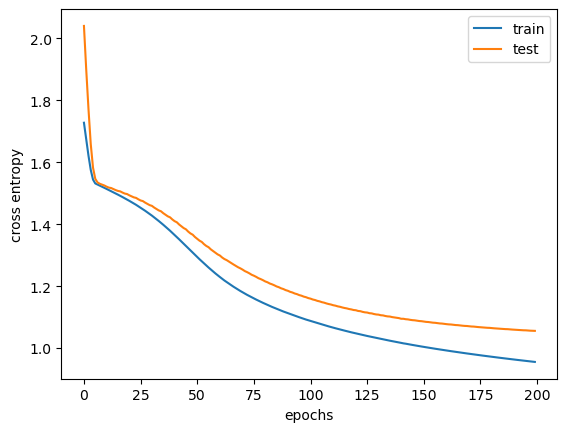

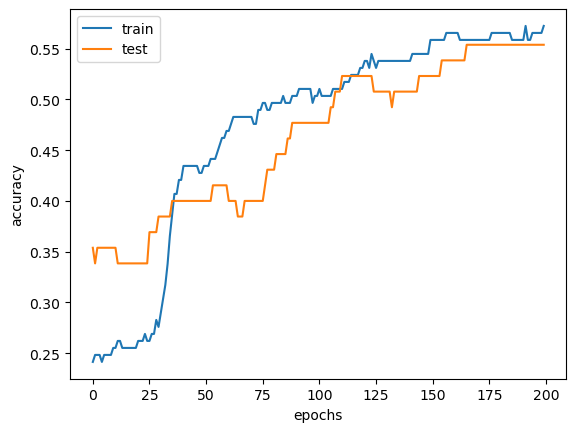

In [20]:
# Plot the loss and accuracy
plt.plot(train_loss_hist, label="train")
plt.plot(test_loss_hist, label="test")
plt.xlabel("epochs")
plt.ylabel("cross entropy")
plt.legend()
plt.show()

plt.plot(train_acc_hist, label="train")
plt.plot(test_acc_hist, label="test")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()